# Action Recognition in Videos - UCF101

**Deep learning-based human action classification using R(2+1)D-18 with PyTorch**

This notebook covers the complete pipeline:
1. Environment setup & dataset download
2. Dataset exploration & visualization
3. Model architecture overview
4. Training with mixed precision & gradient accumulation
5. Evaluation with comprehensive metrics
6. Visualization of model predictions

**Dataset:** UCF101 - 13,320 videos across 101 human action categories  
**Model:** R(2+1)D-18 pretrained on Kinetics-400  
**Framework:** PyTorch

## 1. Environment Setup

In [29]:
# Verify GPU availability (use Runtime > Change runtime type > GPU in Colab)
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow on CPU.")
    print("Go to Runtime > Change runtime type > Hardware accelerator > GPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [30]:
# Clone the repository
!git clone https://github.com/JaiAdith/action-recognition.git
%cd action-recognition

Cloning into 'action-recognition'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 86 (delta 35), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 41.03 KiB | 608.00 KiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/action-recognition/action-recognition


In [31]:
# Install dependencies
!pip install -q -r requirements.txt

## 2. Download UCF101 Dataset

UCF101 contains 13,320 video clips across 101 action categories collected from YouTube.  
Categories include sports (Basketball, Cricket), daily activities (Brushing Teeth, Cooking), and playing instruments.

In [32]:
!apt-get -qq install -y unrar
!wget --no-check-certificate -c https://www.crcv.ucf.edu/data/UCF101/UCF101.rar -O /content/UCF101.rar
!mkdir -p data
!unrar x /content/UCF101.rar ./data/

Streaming output truncated to the last 5000 lines.
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi      62%  OK 
Extracting  ./data/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi      62%  OK 
Extracting  ./data/UCF-101/Pl

## 3. Dataset Exploration & Visualization

In [33]:
import os
from pathlib import Path

data_dir = Path("./data/UCF-101")
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
total_videos = sum(1 for _ in data_dir.rglob("*.avi"))

print(f"Number of classes: {len(classes)}")
print(f"Total videos: {total_videos}")
print(f"\nSample classes: {classes[:10]}")
print(f"Last classes: {classes[-5:]}")

Number of classes: 101
Total videos: 13320

Sample classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']
Last classes: ['VolleyballSpiking', 'WalkingWithDog', 'WallPushups', 'WritingOnBoard', 'YoYo']


Videos per class - Min: 100, Max: 167, Mean: 132, Median: 131


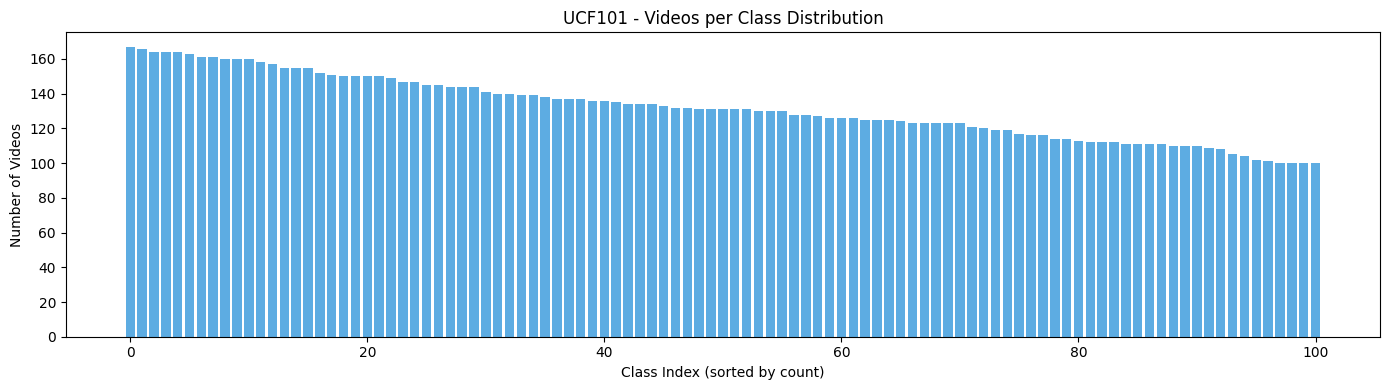

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Count videos per class
class_counts = {}
for cls_dir in sorted(data_dir.iterdir()):
    if cls_dir.is_dir():
        count = len(list(cls_dir.glob("*.avi")))
        class_counts[cls_dir.name] = count

counts = list(class_counts.values())
print(f"Videos per class - Min: {min(counts)}, Max: {max(counts)}, "
      f"Mean: {np.mean(counts):.0f}, Median: {np.median(counts):.0f}")

# Plot distribution
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(counts)), sorted(counts, reverse=True), color="#3498db", alpha=0.8)
ax.set_xlabel("Class Index (sorted by count)")
ax.set_ylabel("Number of Videos")
ax.set_title("UCF101 - Videos per Class Distribution")
plt.tight_layout()
plt.show()

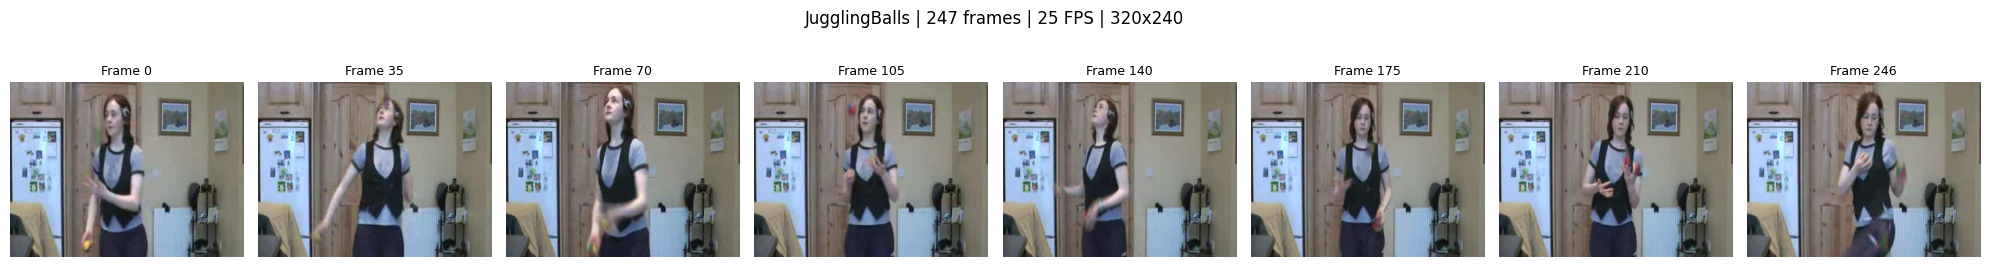

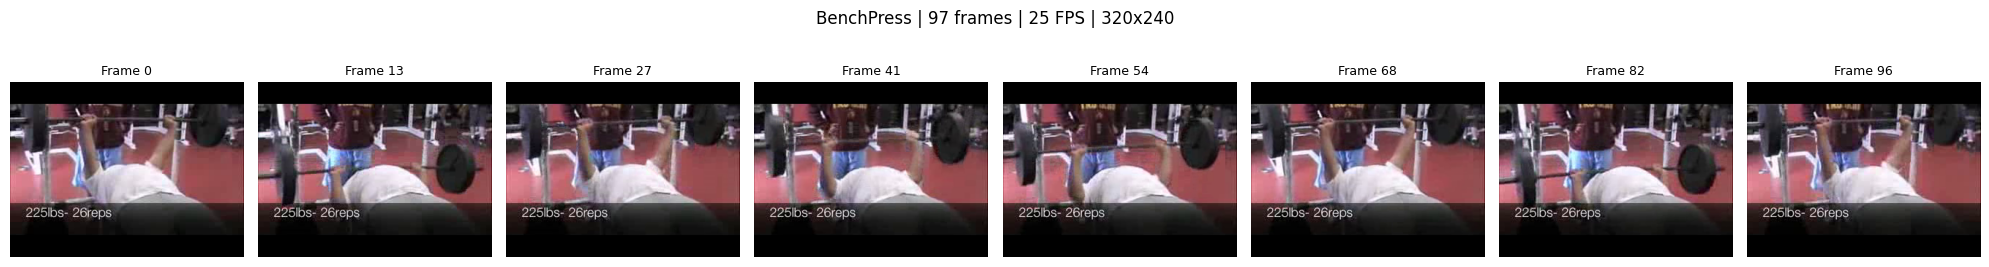

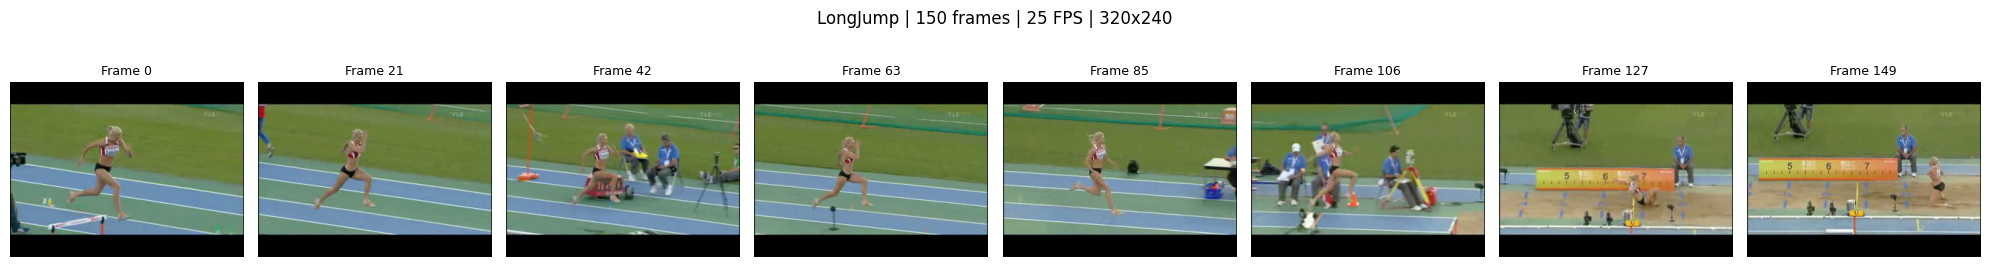

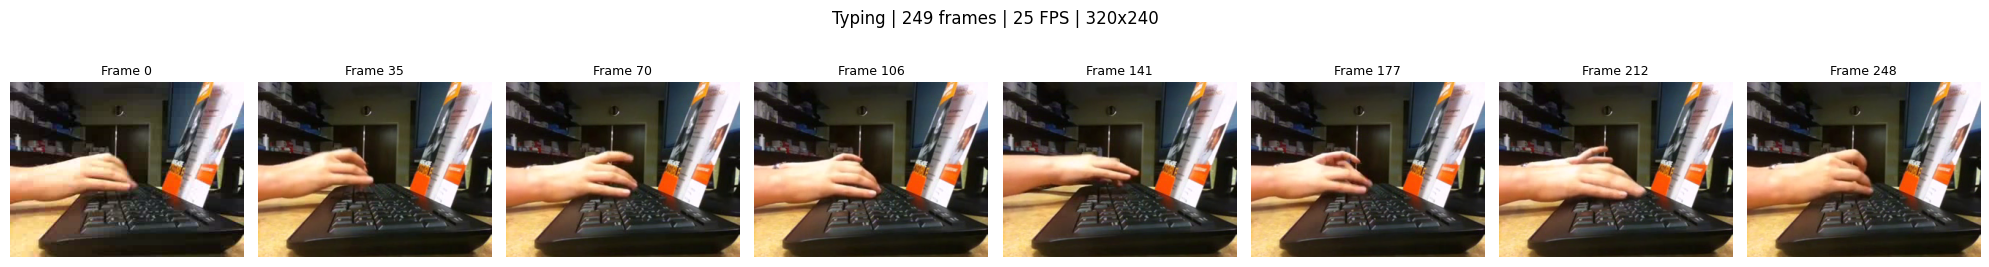

In [35]:
import random

def show_video_frames(video_path, num_frames=8):
    """Display evenly spaced frames from a video."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()

    if not frames:
        print(f"  Skipping {video_path.name} — no readable frames")
        return

    class_name = video_path.parent.name
    fig, axes = plt.subplots(1, len(frames), figsize=(2.5 * len(frames), 3))
    if len(frames) == 1:
        axes = [axes]
    fig.suptitle(f"{class_name} | {total} frames | {fps:.0f} FPS | {w}x{h}", fontsize=12)
    for ax, (idx, frame) in zip(axes, frames):
        ax.imshow(frame)
        ax.set_title(f"Frame {idx}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Show samples from 4 random classes
sample_classes = random.sample(classes, 4)
for cls_name in sample_classes:
    cls_dir = data_dir / cls_name
    video = random.choice(list(cls_dir.glob("*.avi")))
    show_video_frames(video)

## 4. Configuration

All hyperparameters are centralized in `configs/default.yaml`. Key settings:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Clip length | 16 frames | Standard for 3D CNNs |
| Frame stride | 2 | Effective 32-frame temporal window |
| Crop size | 112x112 | Standard for R(2+1)D |
| Batch size | 8 (effective 32) | Fits in GPU memory with gradient accumulation |
| Learning rate | 0.001 | With cosine annealing + 1-epoch warmup |
| Mixed precision | Yes | Reduces VRAM usage by ~40% |

In [44]:
import yaml
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

with open("configs/default.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Colab /dev/shm is limited — avoid multiprocessing for video loading
cfg["data"]["num_workers"] = 0
cfg["training"]["epochs"] = 5

# Display configuration
for section, values in cfg.items():
    print(f"\n[{section}]")
    if isinstance(values, dict):
        for k, v in values.items():
            print(f"  {k}: {v}")
    else:
        print(f"  {values}")


[seed]
  42

[data]
  dataset: ucf101
  root_dir: ./data/UCF-101
  annotation_dir: ./data/ucfTrainTestlist
  split: 1
  num_classes: 101
  clip_length: 16
  frame_stride: 2
  resize: [128, 171]
  crop_size: 112
  num_workers: 0

[training]
  batch_size: 8
  epochs: 5
  learning_rate: 0.001
  weight_decay: 0.0001
  momentum: 0.9
  scheduler: cosine
  warmup_epochs: 1
  mixed_precision: True
  gradient_accumulation_steps: 4
  checkpoint_dir: ./results/checkpoints
  log_dir: ./results/logs

[model]
  architecture: r2plus1d_18
  pretrained: True
  freeze_bn: False
  dropout: 0.5

[augmentation]
  random_horizontal_flip: True
  random_crop: True
  color_jitter: {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2, 'hue': 0.1}
  temporal_jitter: True

[evaluation]
  batch_size: 16
  num_clips: 5


## 5. Dataset & DataLoader

The preprocessing pipeline:
1. **Frame extraction** from video using OpenCV
2. **Temporal sampling**: 16 frames with stride 2 (32-frame window)
3. **Spatial transforms**: Resize to 128x171, crop to 112x112
4. **Augmentation** (train only): Random crop, horizontal flip, color jitter, temporal jitter
5. **Normalization**: ImageNet mean/std (required for pretrained backbone)

In [37]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip -O /tmp/splits.zip
!unzip -qo /tmp/splits.zip -d data/

--2026-08-18 08:34:33--  https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 113943 (111K) [application/zip]
Saving to: ‘/tmp/splits.zip’

/tmp/splits.zip     100%[===================>] 111.27K  --.-KB/s    in 0.1s    

2026-08-18 08:34:33 (937 KB/s) - ‘/tmp/splits.zip’ saved [113943/113943]



In [38]:
import sys
sys.path.insert(0, ".")

from data.dataset import build_dataloaders, UCF101Dataset
from utils.setup import set_seed, get_device

set_seed(cfg["seed"])
device = get_device()

train_loader, test_loader, num_classes = build_dataloaders(cfg)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Number of classes: {num_classes}")

Using GPU: Tesla T4
GPU Memory: 15.6 GB
Train split 1: 9537 videos, 101 classes
Test split 1: 3783 videos, 101 classes

Train batches: 1192
Test batches: 237
Number of classes: 101


In [39]:
# Inspect a training batch
clips, labels = next(iter(train_loader))
print(f"Clip tensor shape: {clips.shape}")  # (B, C, T, H, W)
print(f"  Batch size: {clips.shape[0]}")
print(f"  Channels: {clips.shape[1]}")
print(f"  Frames: {clips.shape[2]}")
print(f"  Height x Width: {clips.shape[3]}x{clips.shape[4]}")
print(f"Labels shape: {labels.shape}")
print(f"Label values: {labels.tolist()}")
print(f"Corresponding classes: {[train_loader.dataset.classes[l] for l in labels.tolist()]}")

Clip tensor shape: torch.Size([8, 3, 16, 112, 112])
  Batch size: 8
  Channels: 3
  Frames: 16
  Height x Width: 112x112
Labels shape: torch.Size([8])
Label values: [35, 62, 47, 54, 91, 26, 33, 63]
Corresponding classes: ['HammerThrow', 'PlayingGuitar', 'JumpRope', 'MoppingFloor', 'TennisSwing', 'Drumming', 'Haircut', 'PlayingPiano']


## 6. Model Architecture

### R(2+1)D-18

R(2+1)D factorizes each 3D convolution into:
- A **2D spatial convolution** (captures appearance)
- A **1D temporal convolution** (captures motion)

Benefits over standard 3D convolutions:
- Doubles the number of nonlinearities (ReLU between spatial and temporal)
- Easier optimization
- Fewer parameters for same representational capacity

The model is pretrained on **Kinetics-400** (400 action classes, ~240K videos) and fine-tuned on UCF101 with a replaced classification head (512 -> 101 classes with dropout).

In [40]:
from models.video_classifier import build_model

model = build_model(cfg).to(device)
print(f"\nArchitecture: {cfg['model']['architecture']}")
print(f"Pretrained: {cfg['model']['pretrained']}")
print(f"Dropout: {cfg['model']['dropout']}")

Loading r2plus1d_18 with Kinetics-400 pretrained weights
Total parameters: 31,351,938
Trainable parameters: 31,351,938

Architecture: r2plus1d_18
Pretrained: True
Dropout: 0.5


In [41]:
# Verify forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 16, 112, 112).to(device)
    out = model(dummy)
    print(f"Input shape:  {dummy.shape}  (B, C, T, H, W)")
    print(f"Output shape: {out.shape}  (B, num_classes)")
    print(f"Output range: [{out.min():.3f}, {out.max():.3f}]")

Input shape:  torch.Size([2, 3, 16, 112, 112])  (B, C, T, H, W)
Output shape: torch.Size([2, 101])  (B, num_classes)
Output range: [-1.670, 1.802]


## 7. Training

Training strategy:
- **Optimizer:** SGD with momentum (0.9) and weight decay (1e-4)
- **Scheduler:** Cosine annealing with 1-epoch linear warmup
- **Mixed precision (AMP):** Reduces VRAM usage for smaller GPUs
- **Gradient accumulation:** 4 steps for effective batch size of 32
- **Checkpointing:** Saves best and latest model weights

In [42]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler, autocast
from tqdm.notebook import tqdm
import time
import csv
import math

# Reinitialize model for training
set_seed(cfg["seed"])
model = build_model(cfg).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=cfg["training"]["learning_rate"],
    momentum=cfg["training"]["momentum"],
    weight_decay=cfg["training"]["weight_decay"],
)

# Cosine annealing with warmup (computed in optimizer steps, not batch steps)
accum_steps = cfg["training"]["gradient_accumulation_steps"]
steps_per_epoch = len(train_loader)
optim_steps_per_epoch = (steps_per_epoch + accum_steps - 1) // accum_steps
total_steps = cfg["training"]["epochs"] * optim_steps_per_epoch
warmup_steps = cfg["training"]["warmup_epochs"] * optim_steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler(enabled=cfg["training"]["mixed_precision"])

# Create output dirs
from pathlib import Path
ckpt_dir = Path(cfg["training"]["checkpoint_dir"])
log_dir = Path(cfg["training"]["log_dir"])
ckpt_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

print(f"Batch steps per epoch: {steps_per_epoch}")
print(f"Optimizer steps per epoch: {optim_steps_per_epoch}")
print(f"Total optimizer steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Effective batch size: {cfg['training']['batch_size'] * accum_steps}")

Loading r2plus1d_18 with Kinetics-400 pretrained weights
Total parameters: 31,351,938
Trainable parameters: 31,351,938
Batch steps per epoch: 1192
Optimizer steps per epoch: 298
Total optimizer steps: 5960
Warmup steps: 298
Effective batch size: 32


In [45]:
# Training loop
num_epochs = cfg["training"]["epochs"]
use_amp = cfg["training"]["mixed_precision"]
best_acc = 0.0

history = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_top1": [], "test_top5": [],
    "lr": [],
}

log_file = log_dir / "training_log.csv"
with open(log_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "test_loss", "test_top1", "test_top5", "lr"])

for epoch in range(num_epochs):
    epoch_start = time.time()

    # === Train ===
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs-1} [Train]")
    for batch_idx, (clips, labels) in enumerate(pbar):
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=device.type, enabled=use_amp):
            outputs = model(clips)
            loss = criterion(outputs, labels) / accum_steps

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0 or (batch_idx + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        running_loss += loss.item() * accum_steps
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (batch_idx + 1)
        acc = 100.0 * correct / total
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.1f}%")

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total

    # === Evaluate ===
    model.eval()
    test_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total_test = 0

    with torch.no_grad():
        for clips, labels in tqdm(test_loader, desc=f"Epoch {epoch}/{num_epochs-1} [Test]", leave=False):
            clips = clips.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(device_type=device.type, enabled=use_amp):
                outputs = model(clips)
                loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, pred = outputs.max(1)
            total_test += labels.size(0)
            correct_top1 += pred.eq(labels).sum().item()

            _, pred5 = outputs.topk(5, dim=1)
            correct_top5 += sum(labels[i] in pred5[i] for i in range(labels.size(0)))

    test_loss /= len(test_loader)
    top1_acc = 100.0 * correct_top1 / total_test
    top5_acc = 100.0 * correct_top5 / total_test
    lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start

    # Log
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_top1"].append(top1_acc)
    history["test_top5"].append(top5_acc)
    history["lr"].append(lr)

    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, f"{train_loss:.4f}", f"{train_acc:.2f}",
                         f"{test_loss:.4f}", f"{top1_acc:.2f}", f"{top5_acc:.2f}", f"{lr:.6f}"])

    print(f"Epoch {epoch} ({epoch_time:.0f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Test Top-1: {top1_acc:.1f}% Top-5: {top5_acc:.1f}%")

    # Save checkpoints
    metrics = {"train_loss": train_loss, "train_acc": train_acc,
               "test_top1": top1_acc, "test_top5": top5_acc, "best_acc": max(best_acc, top1_acc)}
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "metrics": metrics}, ckpt_dir / "latest.pth")

    if top1_acc > best_acc:
        best_acc = top1_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "scaler_state_dict": scaler.state_dict(),
                    "metrics": metrics}, ckpt_dir / "best.pth")
        print(f"  >> New best model: {top1_acc:.2f}%")

print(f"\nTraining complete! Best Top-1: {best_acc:.2f}%")

Epoch 0/4 [Train]:   0%|          | 0/1192 [00:00<?, ?it/s]

Epoch 0/4 [Test]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 0 (830s) | Train Loss: 3.4759 Acc: 28.5% | Test Top-1: 72.6% Top-5: 94.8%
  >> New best model: 72.56%


Epoch 1/4 [Train]:   0%|          | 0/1192 [00:00<?, ?it/s]

Epoch 1/4 [Test]:   0%|          | 0/237 [00:00<?, ?it/s]

...

Epoch 3/4 [Test]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 3 (833s) | Train Loss: 0.8344 Acc: 83.1% | Test Top-1: 89.3% Top-5: 98.6%
  >> New best model: 89.27%


Epoch 4/4 [Train]:   0%|          | 0/1192 [00:00<?, ?it/s]

Epoch 4/4 [Test]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 4 (818s) | Train Loss: 0.6720 Acc: 86.0% | Test Top-1: 89.8% Top-5: 98.8%
  >> New best model: 89.80%

Training complete! Best Top-1: 89.80%


## 8. Training Curves

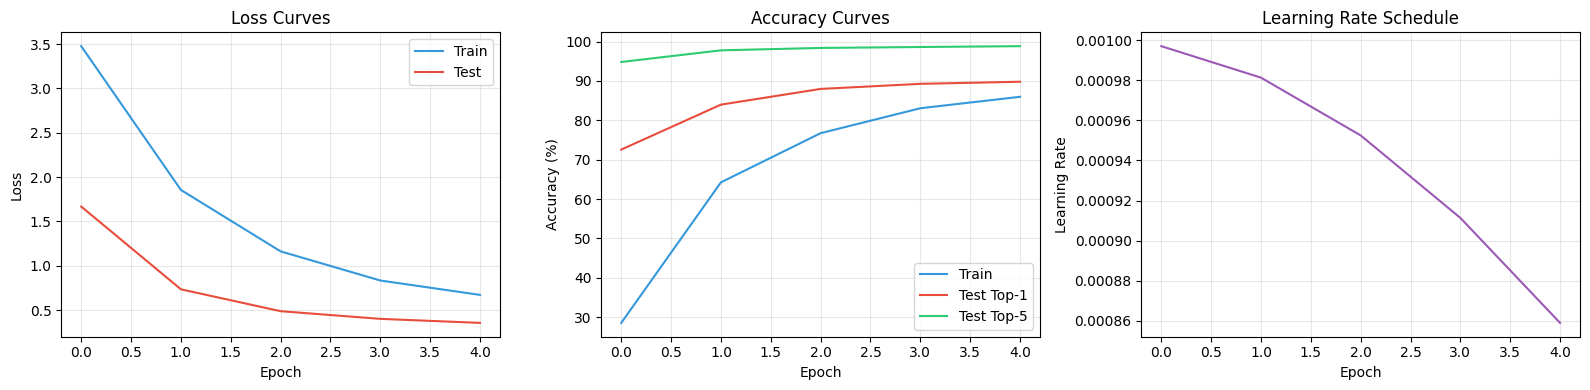

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(len(history["train_loss"]))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#3498db")
axes[0].plot(epochs_range, history["test_loss"], label="Test", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], label="Train", color="#3498db")
axes[1].plot(epochs_range, history["test_top1"], label="Test Top-1", color="#e74c3c")
axes[1].plot(epochs_range, history["test_top5"], label="Test Top-5", color="#2ecc71")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Curves")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs_range, history["lr"], color="#9b59b6")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/evaluation/training_curves.png", dpi=150)
plt.show()

## 9. Comprehensive Evaluation

Evaluation metrics:
- **Top-1 Accuracy:** Correct if the highest predicted class matches the true label
- **Top-5 Accuracy:** Correct if the true label is among the 5 highest predictions
- **Confusion Matrix:** Visualizes class-wise prediction patterns
- **Per-class Precision, Recall, F1-score:** Detailed per-action performance
- **Inference Time:** Milliseconds per video clip

In [47]:
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support, top_k_accuracy_score
)
import seaborn as sns

# Load best checkpoint
checkpoint = torch.load(ckpt_dir / "best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

# Collect predictions
model.eval()
all_preds, all_labels, all_probs = [], [], []
inference_times = []

with torch.no_grad():
    for clips, labels in tqdm(test_loader, desc="Evaluating"):
        clips = clips.to(device, non_blocking=True)

        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()

        with autocast(device_type=device.type, enabled=use_amp):
            outputs = model(clips)

        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.time() - start

        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        inference_times.append(elapsed / clips.size(0))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

class_names = test_loader.dataset.classes

# Compute metrics
top1_acc = 100.0 * np.mean(all_preds == all_labels)
top5_acc = 100.0 * top_k_accuracy_score(all_labels, all_probs, k=5, labels=range(num_classes))
avg_inference_ms = np.mean(inference_times) * 1000

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=range(num_classes), zero_division=0
)

print(f"\n{'='*50}")
print(f"Top-1 Accuracy:      {top1_acc:.2f}%")
print(f"Top-5 Accuracy:      {top5_acc:.2f}%")
print(f"Macro Precision:     {precision.mean():.4f}")
print(f"Macro Recall:        {recall.mean():.4f}")
print(f"Macro F1-Score:      {f1.mean():.4f}")
print(f"Avg Inference Time:  {avg_inference_ms:.1f} ms/clip")
print(f"{'='*50}")

Loaded best checkpoint from epoch 4


Evaluating:   0%|          | 0/237 [00:00<?, ?it/s]


Top-1 Accuracy:      89.80%
Top-5 Accuracy:      98.84%
Macro Precision:     0.9046
Macro Recall:        0.8960
Macro F1-Score:      0.8932
Avg Inference Time:  11.5 ms/clip


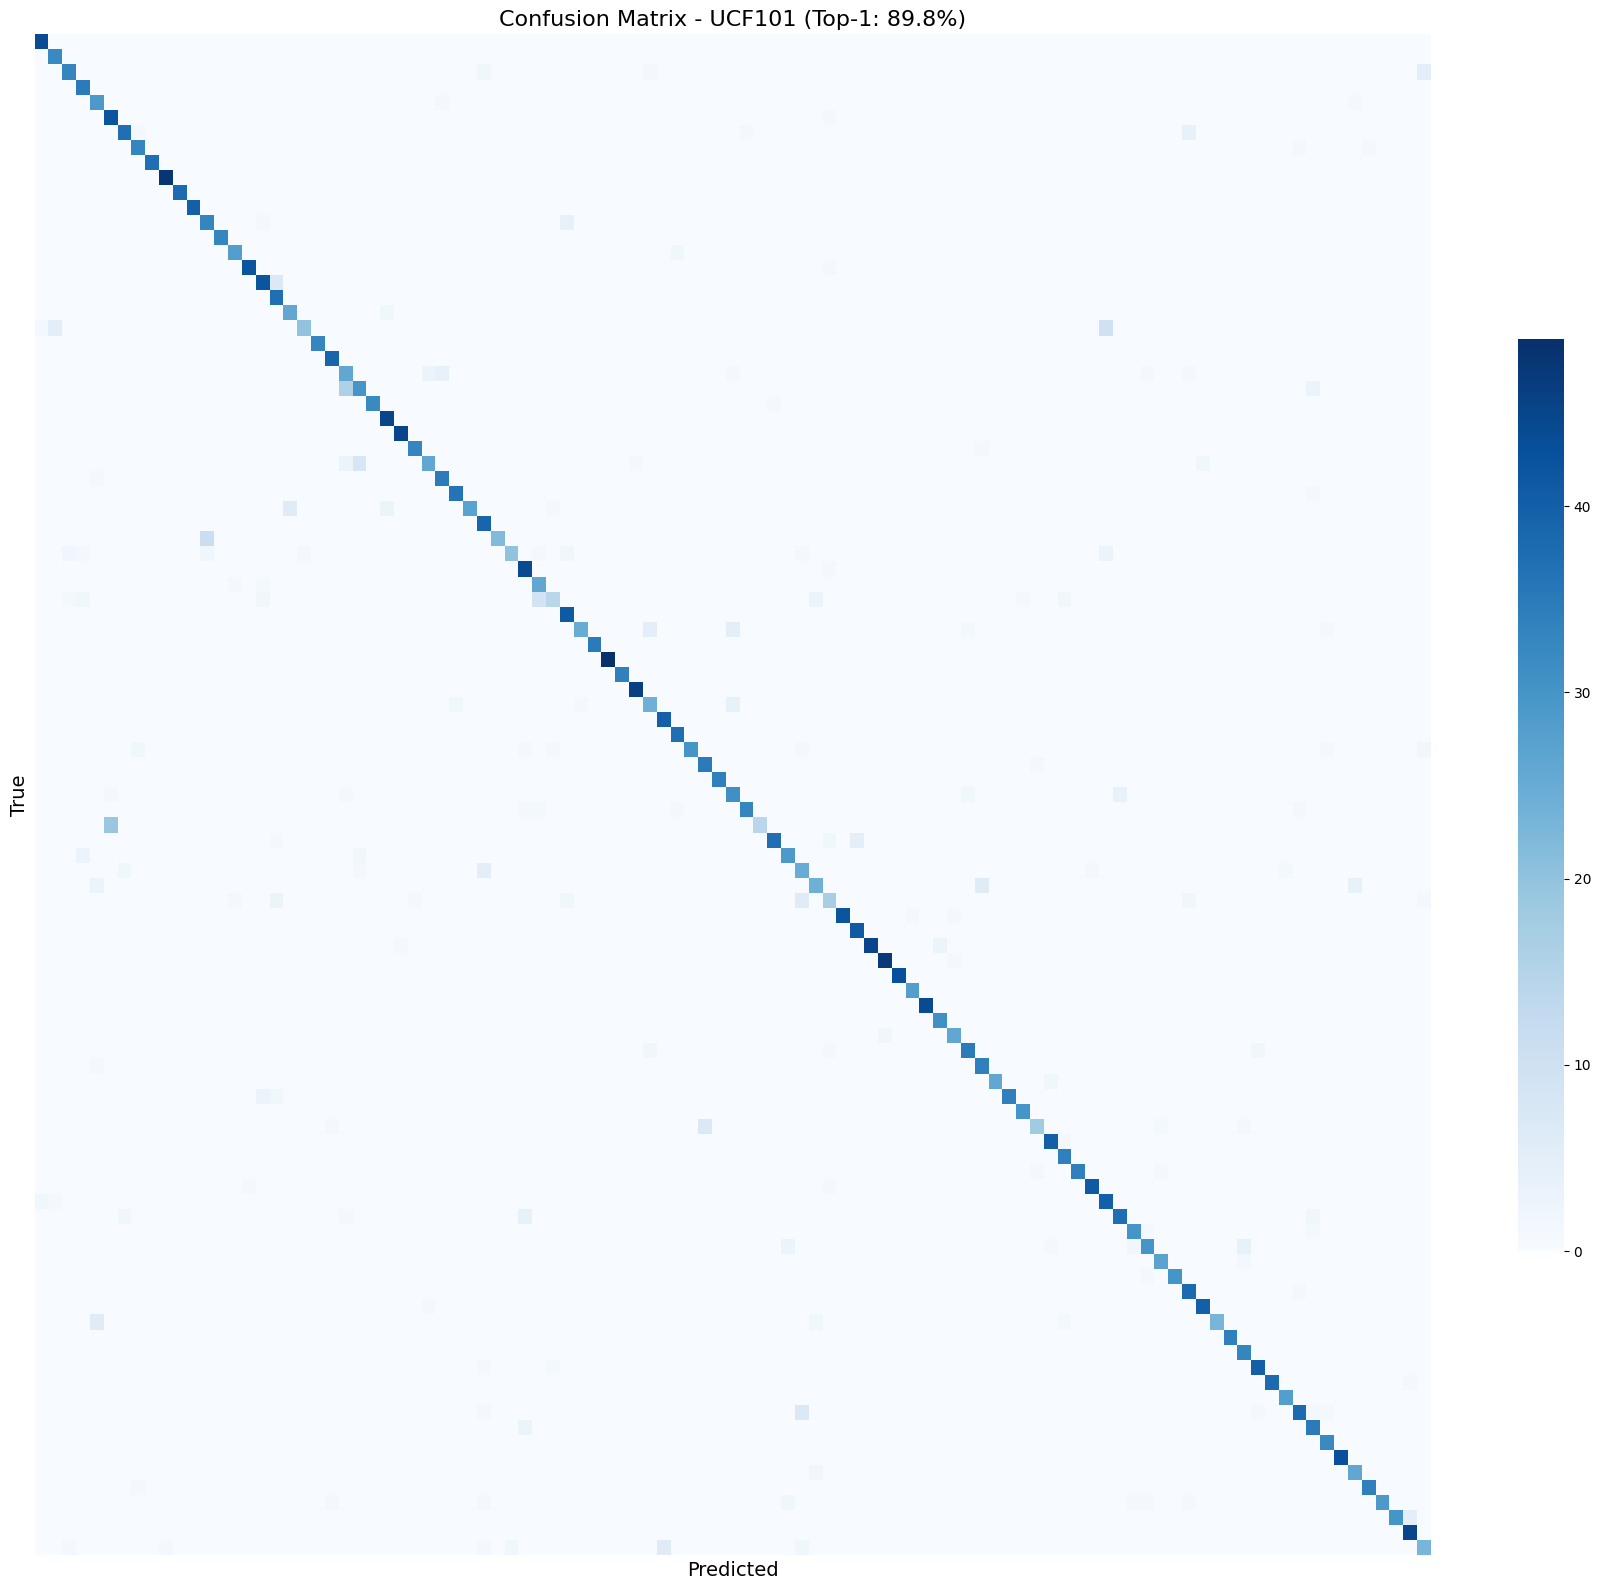

In [48]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False,
            ax=ax, cbar_kws={"shrink": 0.6})
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("True", fontsize=14)
ax.set_title(f"Confusion Matrix - UCF101 (Top-1: {top1_acc:.1f}%)", fontsize=16)
plt.tight_layout()
plt.savefig("results/evaluation/confusion_matrix.png", dpi=150)
plt.show()

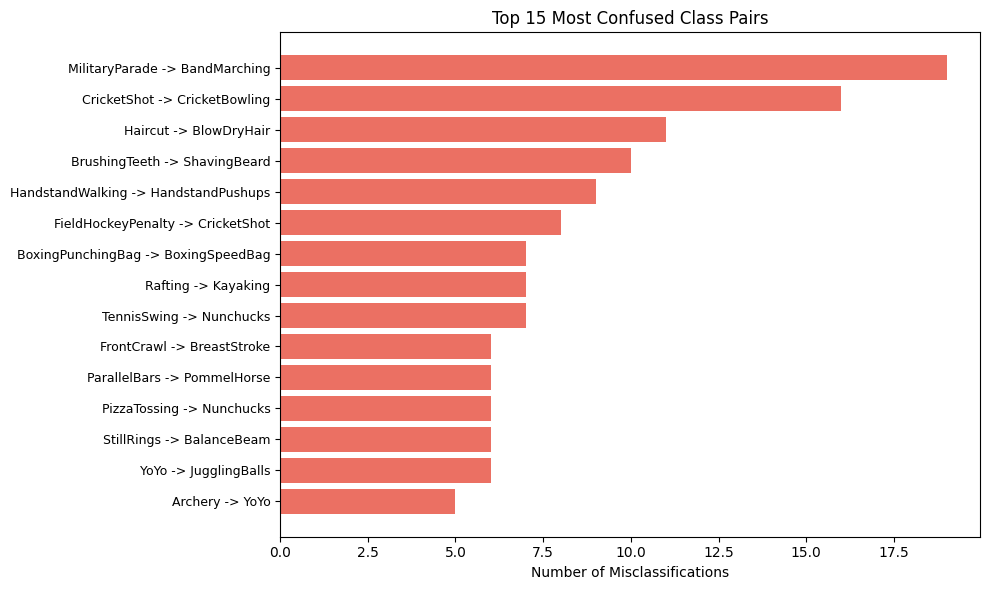

In [49]:
# Top confused class pairs
cm_off = cm.copy().astype(float)
np.fill_diagonal(cm_off, 0)

pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_off[i, j] > 0:
            pairs.append((class_names[i], class_names[j], cm_off[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)
top_pairs = pairs[:15]

labels_plot = [f"{p[0]} -> {p[1]}" for p in top_pairs]
values_plot = [p[2] for p in top_pairs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(labels_plot)), values_plot, color="#e74c3c", alpha=0.8)
ax.set_yticks(range(len(labels_plot)))
ax.set_yticklabels(labels_plot, fontsize=9)
ax.set_xlabel("Number of Misclassifications")
ax.set_title("Top 15 Most Confused Class Pairs")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("results/evaluation/top_confused_pairs.png", dpi=150)
plt.show()

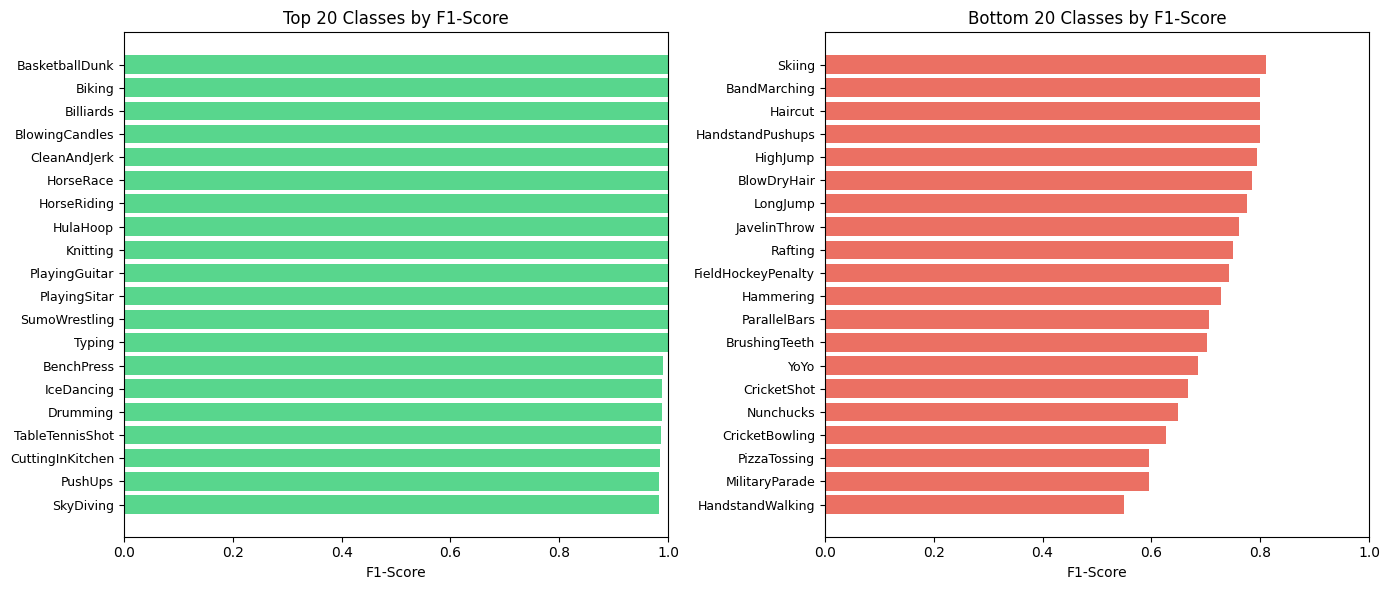

In [50]:
# Per-class F1-score visualization (top 20 and bottom 20)
class_f1 = list(zip(class_names, f1))
class_f1.sort(key=lambda x: x[1], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top 20
top20 = class_f1[:20]
ax1.barh(range(len(top20)), [x[1] for x in top20], color="#2ecc71", alpha=0.8)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels([x[0] for x in top20], fontsize=9)
ax1.set_xlabel("F1-Score")
ax1.set_title("Top 20 Classes by F1-Score")
ax1.set_xlim(0, 1)
ax1.invert_yaxis()

# Bottom 20
bottom20 = class_f1[-20:]
ax2.barh(range(len(bottom20)), [x[1] for x in bottom20], color="#e74c3c", alpha=0.8)
ax2.set_yticks(range(len(bottom20)))
ax2.set_yticklabels([x[0] for x in bottom20], fontsize=9)
ax2.set_xlabel("F1-Score")
ax2.set_title("Bottom 20 Classes by F1-Score")
ax2.set_xlim(0, 1)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("results/evaluation/per_class_f1.png", dpi=150)
plt.show()

In [51]:
import json

# Save per-class metrics to CSV
eval_dir = Path("results/evaluation")
eval_dir.mkdir(parents=True, exist_ok=True)

with open(eval_dir / "per_class_metrics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["class", "precision", "recall", "f1_score", "support"])
    for i, name in enumerate(class_names):
        writer.writerow([name, f"{precision[i]:.4f}", f"{recall[i]:.4f}",
                         f"{f1[i]:.4f}", int(support[i])])
    writer.writerow(["MACRO_AVG", f"{precision.mean():.4f}", f"{recall.mean():.4f}",
                     f"{f1.mean():.4f}", int(support.sum())])

# Save summary
summary = {
    "model": cfg["model"]["architecture"],
    "pretrained": "Kinetics-400",
    "epoch": int(checkpoint["epoch"]),
    "top1_accuracy": round(top1_acc, 2),
    "top5_accuracy": round(top5_acc, 2),
    "macro_precision": round(float(precision.mean()), 4),
    "macro_recall": round(float(recall.mean()), 4),
    "macro_f1": round(float(f1.mean()), 4),
    "avg_inference_time_ms": round(avg_inference_ms, 1),
    "num_test_samples": int(len(all_labels)),
}
with open(eval_dir / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Evaluation results saved to results/evaluation/")
print(json.dumps(summary, indent=2))

Evaluation results saved to results/evaluation/
{
  "model": "r2plus1d_18",
  "pretrained": "Kinetics-400",
  "epoch": 4,
  "top1_accuracy": 89.8,
  "top5_accuracy": 98.84,
  "macro_precision": 0.9046,
  "macro_recall": 0.896,
  "macro_f1": 0.8932,
  "avg_inference_time_ms": 11.5,
  "num_test_samples": 3783
}


## 10. Visualize Predictions on Sample Videos

Generate annotated visualizations showing:
- Sample frames from each video
- Top-5 predicted classes with confidence bars
- Green = correct prediction, Red = incorrect

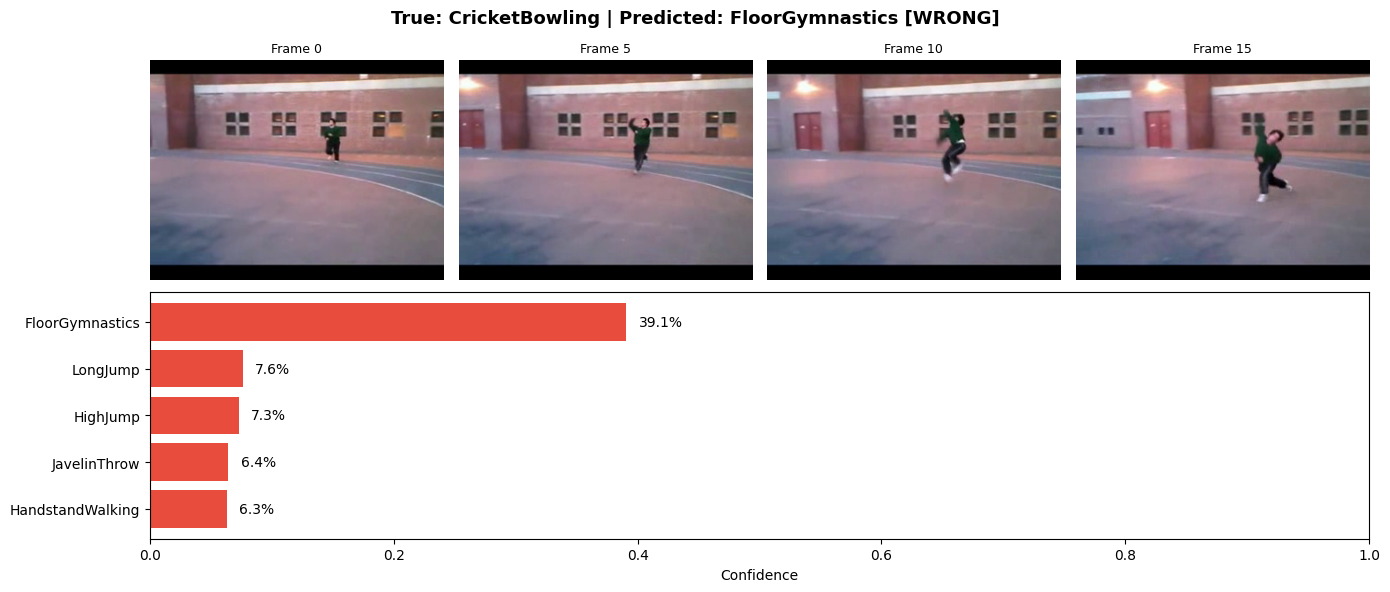

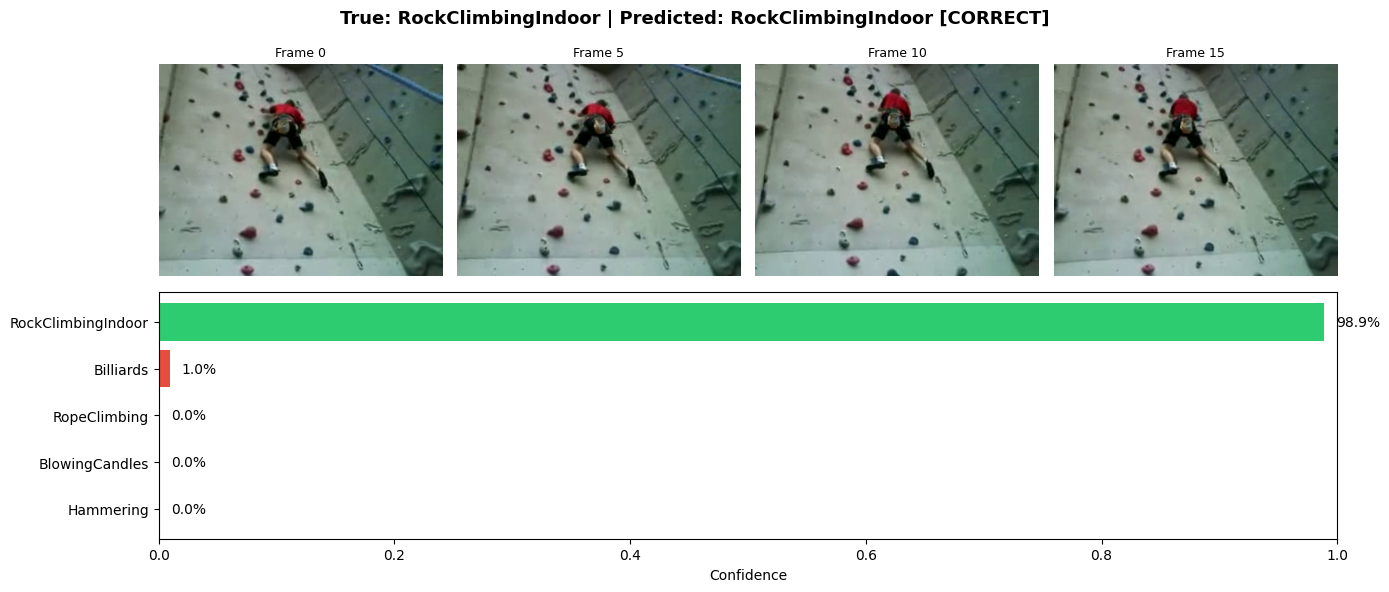

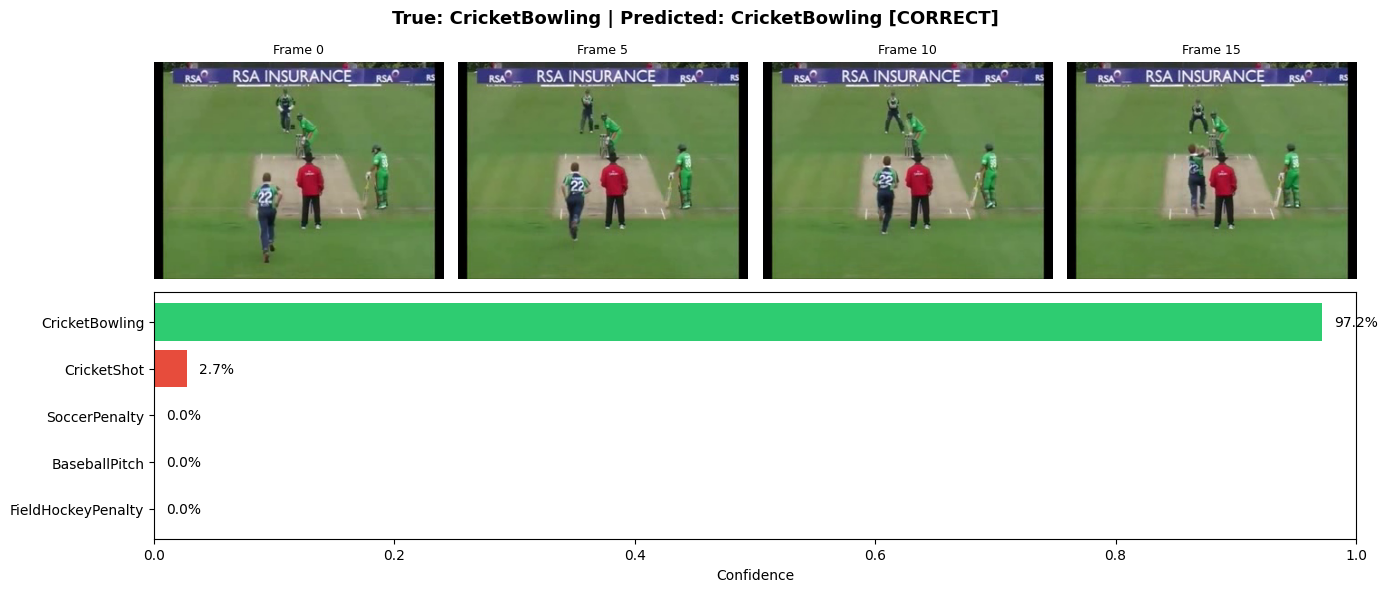

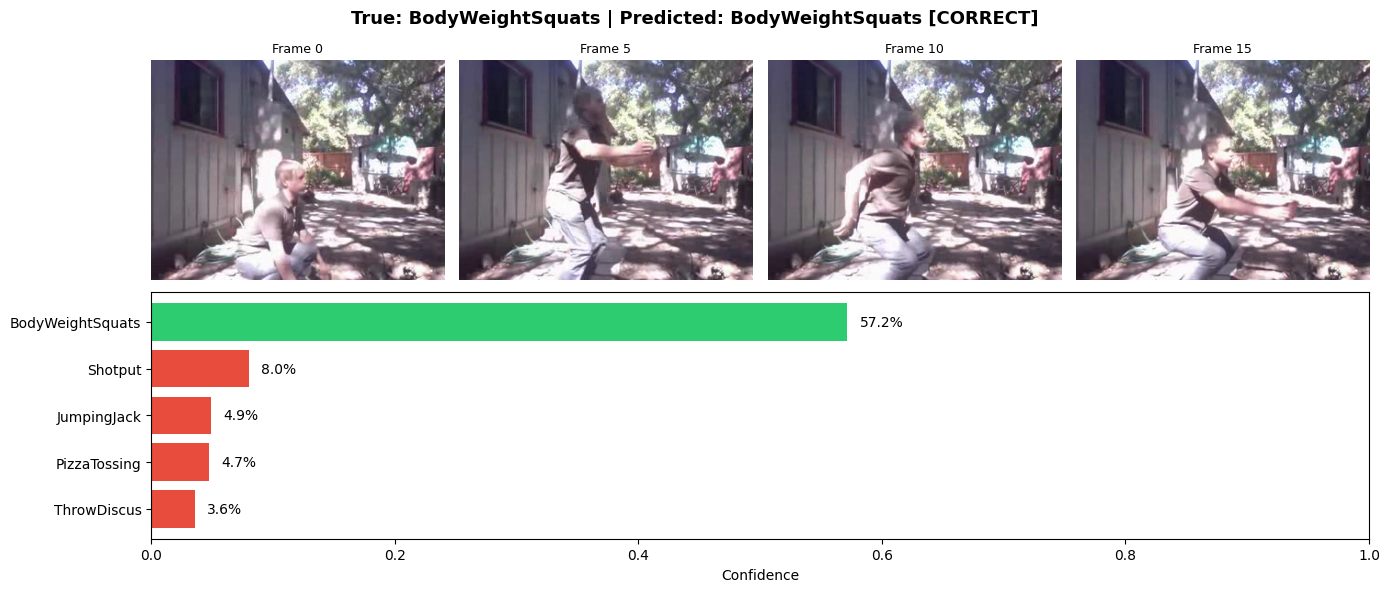

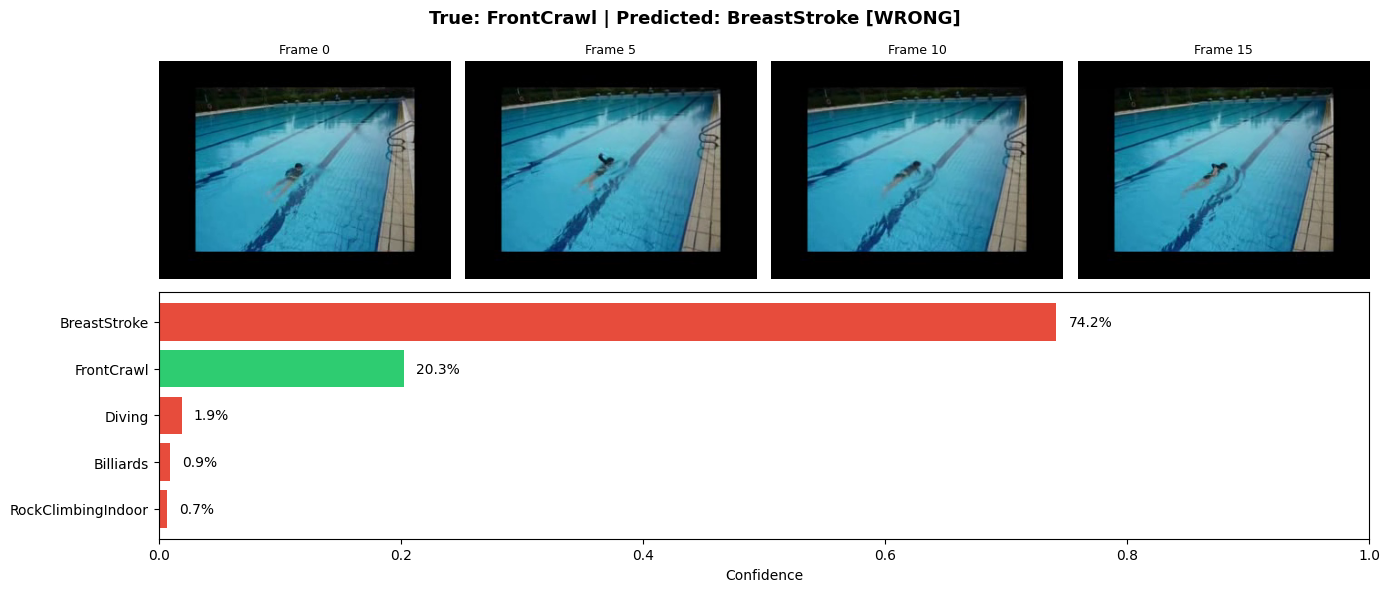

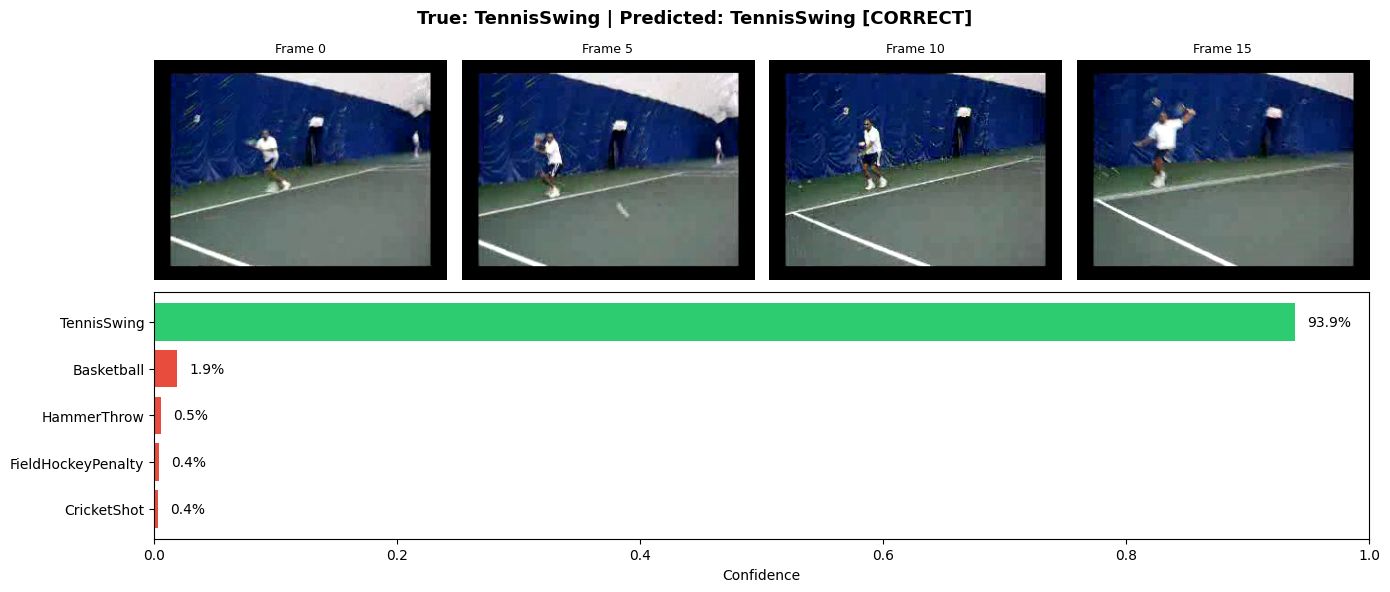

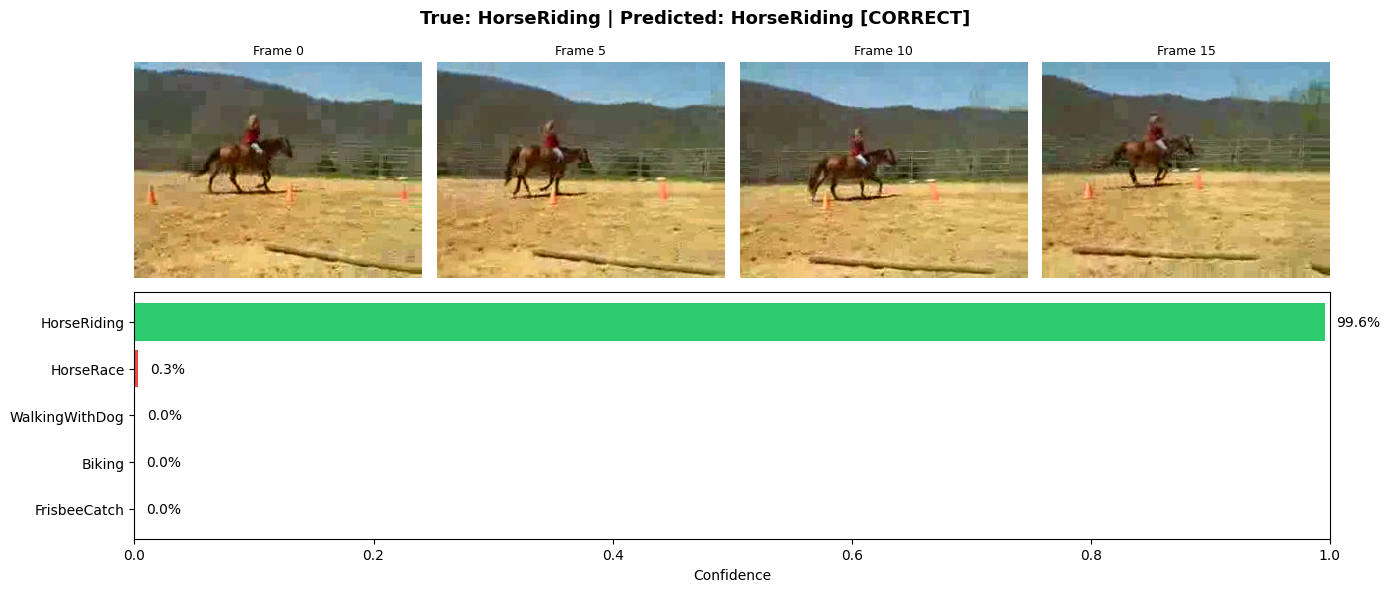

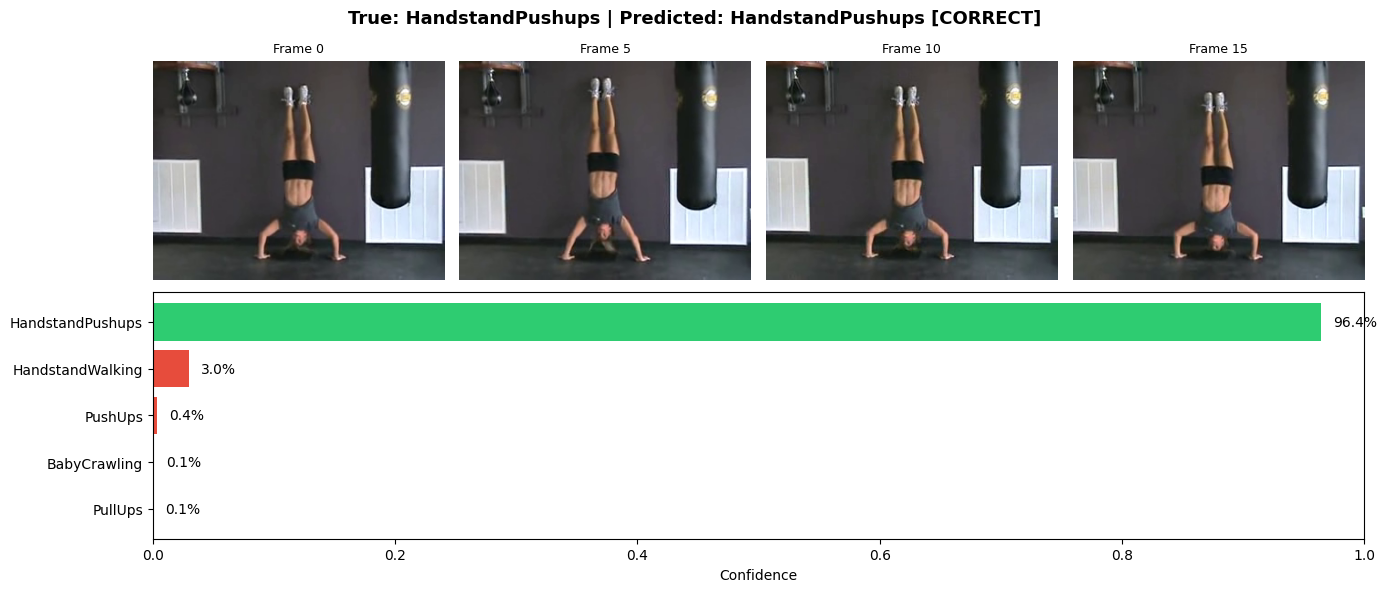

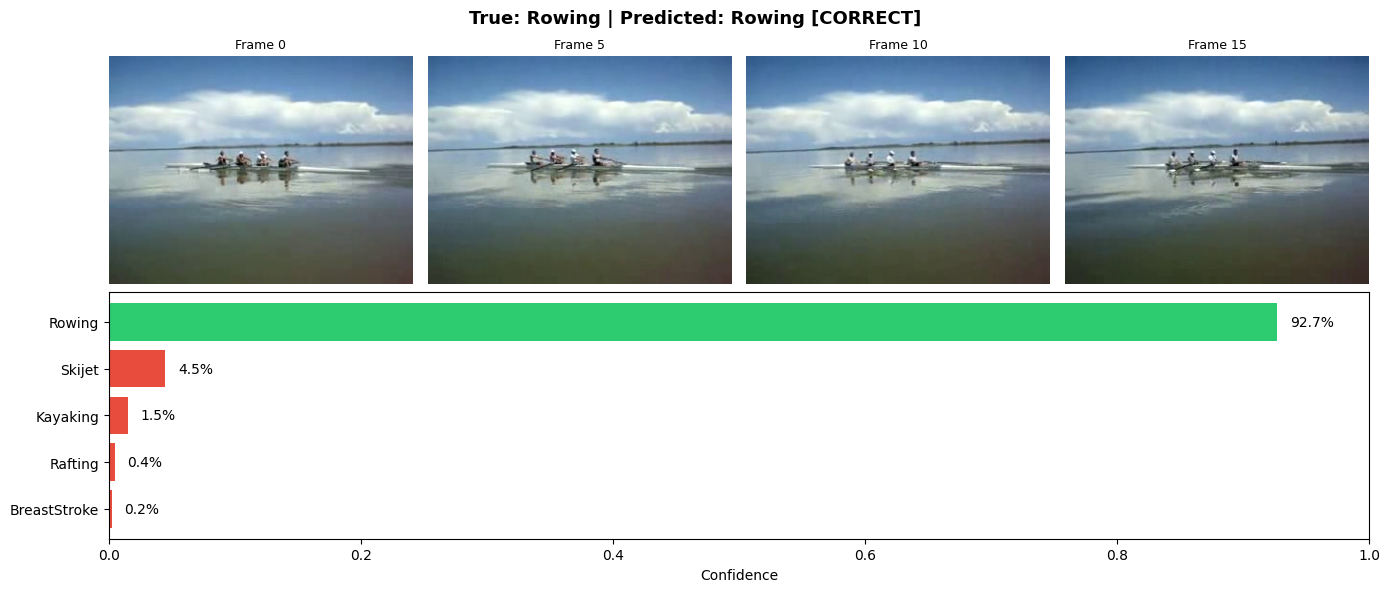

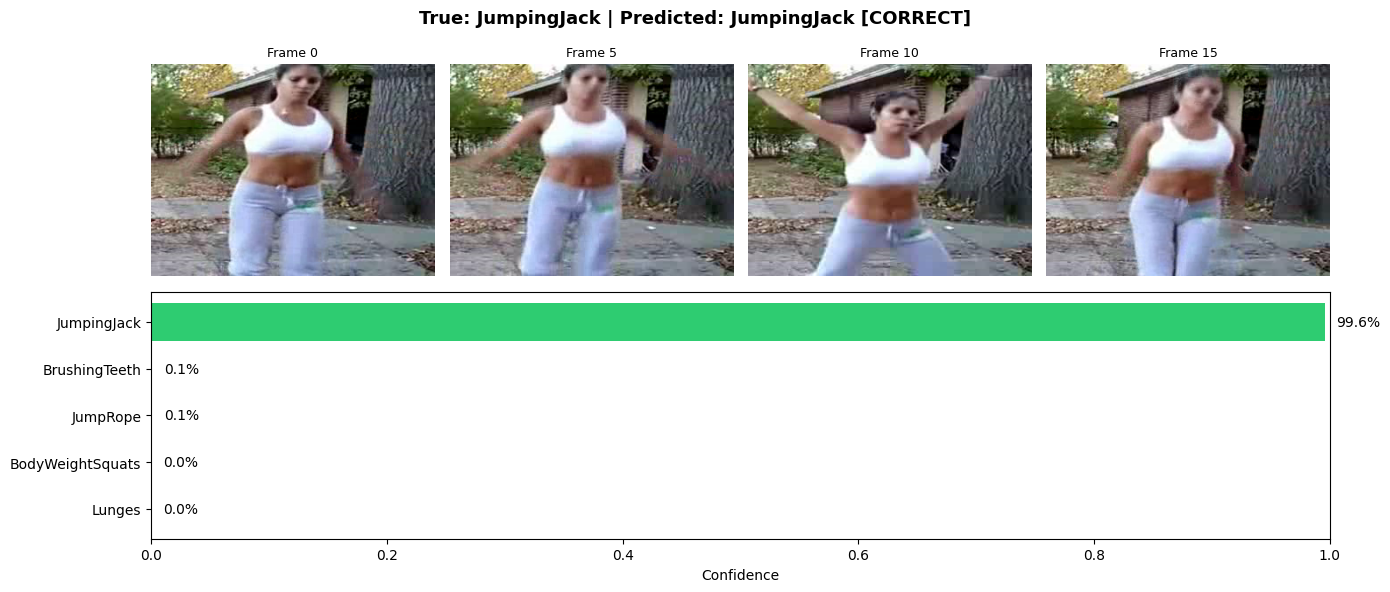


Visualizations saved to results/visualizations/


In [52]:
# Visualize predictions on 10 random test samples
test_dataset = test_loader.dataset
sample_indices = random.sample(range(len(test_dataset)), 10)

for i, idx in enumerate(sample_indices):
    video_path, true_idx = test_dataset.samples[idx]
    true_label = class_names[true_idx]

    # Raw frames for display
    raw_frames = test_dataset._load_frames(video_path)

    # Model prediction
    clip, _ = test_dataset[idx]
    clip = clip.unsqueeze(0).to(device)

    with torch.no_grad():
        with autocast(device_type=device.type, enabled=use_amp):
            output = model(clip)

    probs_sample = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    top5_idx = np.argsort(probs_sample)[-5:][::-1]
    top5_classes = [class_names[j] for j in top5_idx]
    top5_probs = [probs_sample[j] for j in top5_idx]
    pred_label = top5_classes[0]

    # Plot
    fig = plt.figure(figsize=(14, 6))
    num_display = min(4, len(raw_frames))
    frame_indices = np.linspace(0, len(raw_frames) - 1, num_display, dtype=int)

    for fi, fidx in enumerate(frame_indices):
        ax = fig.add_subplot(2, num_display, fi + 1)
        ax.imshow(raw_frames[fidx])
        ax.set_title(f"Frame {fidx}", fontsize=9)
        ax.axis("off")

    ax_bar = fig.add_subplot(2, 1, 2)
    colors = ["#2ecc71" if c == true_label else "#e74c3c" for c in top5_classes]
    bars = ax_bar.barh(range(5), top5_probs, color=colors)
    ax_bar.set_yticks(range(5))
    ax_bar.set_yticklabels(top5_classes, fontsize=10)
    ax_bar.set_xlabel("Confidence")
    ax_bar.set_xlim(0, 1)
    ax_bar.invert_yaxis()
    for bar, prob in zip(bars, top5_probs):
        ax_bar.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{prob:.1%}", va="center", fontsize=10)

    marker = "CORRECT" if pred_label == true_label else "WRONG"
    fig.suptitle(f"True: {true_label} | Predicted: {pred_label} [{marker}]",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"results/visualizations/prediction_{i+1:02d}.png", dpi=150, bbox_inches="tight")
    plt.show()

print(f"\nVisualizations saved to results/visualizations/")

## 11. Summary & Key Findings

### Results

| Metric | Value |
|--------|-------|
| Top-1 Accuracy | See evaluation above |
| Top-5 Accuracy | See evaluation above |
| Macro F1-Score | See evaluation above |
| Inference Time | See evaluation above |

### Architecture Choice: R(2+1)D-18
- Factorized 3D convolutions provide better accuracy than standard R3D-18 with similar compute
- Kinetics-400 pretraining provides strong feature initialization
- 16-frame clips with stride 2 capture sufficient temporal context

### Challenges
1. **GPU memory constraints:** Solved with mixed precision training and gradient accumulation
2. **Similar action classes:** Some categories (e.g., different types of sports) are visually similar
3. **Video loading speed:** OpenCV-based loading can be a bottleneck; could explore decord

### Potential Improvements
1. **Optical flow:** Two-stream architecture combining RGB and motion information
2. **Transformer backbone:** Video Swin Transformer or TimeSformer for better temporal modeling
3. **Multi-clip evaluation:** Average predictions across multiple temporal crops per video
4. **Test-time augmentation:** Flip, multi-crop during inference
5. **Longer training:** More epochs with learning rate restarts

In [53]:
# Download trained model and results (for Colab)
import shutil

# Zip results for download
shutil.make_archive("action_recognition_results", "zip", "results")
print("Results packaged as action_recognition_results.zip")
print("\nFiles included:")
for f in Path("results").rglob("*"):
    if f.is_file() and f.name != ".gitkeep":
        print(f"  {f}")

Results packaged as action_recognition_results.zip

Files included:
  results/evaluation/training_curves.png
  results/evaluation/per_class_f1.png
  results/evaluation/per_class_metrics.csv
  results/evaluation/confusion_matrix.png
  results/evaluation/top_confused_pairs.png
  results/evaluation/evaluation_summary.json
  results/logs/training_log.csv
  results/checkpoints/best.pth
  results/checkpoints/latest.pth
  results/visualizations/prediction_03.png
  results/visualizations/prediction_02.png
  results/visualizations/prediction_08.png
  results/visualizations/prediction_01.png
  results/visualizations/prediction_05.png
  results/visualizations/prediction_10.png
  results/visualizations/prediction_06.png
  results/visualizations/prediction_09.png
  results/visualizations/prediction_07.png
  results/visualizations/prediction_04.png
